In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv")

In [3]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
df.drop(columns = ['RowNumber','CustomerId','Surname' ], inplace = True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [6]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Exited'].value_counts(normalize = True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [9]:
X = df.drop(columns = ['Exited'])
y = df['Exited']

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42,stratify = y)

In [11]:
df.select_dtypes(include = "object").columns

Index(['Geography', 'Gender'], dtype='object')

In [12]:
X_train_mod = pd.get_dummies(X_train,columns = ['Geography', 'Gender'],drop_first = True)
X_test_mod = pd.get_dummies(X_test,columns = ['Geography', 'Gender'],drop_first = True)

In [13]:
X_train_mod

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
2151,753,57,7,0.00,1,1,0,159475.08,False,False,True
8392,739,32,3,102128.27,1,1,0,63981.37,True,False,True
5006,755,37,0,113865.23,2,1,1,117396.25,True,False,False
4117,561,37,5,0.00,2,1,0,83093.25,False,False,True
7182,692,49,6,110540.43,2,0,1,107472.99,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...
4555,688,35,6,0.00,1,1,0,25488.43,False,True,False
4644,712,74,5,0.00,2,0,0,151425.82,False,True,True
8942,667,37,9,71786.90,2,1,1,67734.79,False,False,False
2935,687,35,8,100988.39,2,1,0,22247.27,False,True,True


In [14]:
X_test_mod

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
5702,585,36,7,0.00,2,1,0,94283.09,False,False,True
3667,525,33,4,131023.76,2,0,0,55072.93,True,False,True
1617,557,40,4,0.00,2,0,1,105433.53,False,True,False
5673,639,34,5,139393.19,2,0,0,33950.08,False,True,True
4272,640,34,3,77826.80,1,1,1,168544.85,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
5768,674,36,2,154525.70,1,0,1,27468.72,False,False,True
833,634,37,3,111432.77,2,1,1,167032.49,True,False,True
9719,516,47,9,128298.74,1,0,0,149614.17,True,False,False
2776,689,39,7,0.00,2,0,0,14917.09,False,False,True


In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
scaler = StandardScaler()

In [17]:
X_train_scaled = scaler.fit_transform(X_train_mod)
X_test_scaled = scaler.transform(X_test_mod)

In [18]:
X_train_scaled


array([[ 1.058568  ,  1.71508648,  0.68472287, ..., -0.57831252,
        -0.57773517,  0.90750738],
       [ 0.91362605, -0.65993547, -0.6962018 , ...,  1.72916886,
        -0.57773517,  0.90750738],
       [ 1.07927399, -0.18493108, -1.73189531, ...,  1.72916886,
        -0.57773517, -1.10191942],
       ...,
       [ 0.16821031, -0.18493108,  1.3751852 , ..., -0.57831252,
        -0.57773517, -1.10191942],
       [ 0.37527024, -0.37493284,  1.02995403, ..., -0.57831252,
         1.73089688,  0.90750738],
       [ 1.56586482,  1.14508121,  0.68472287, ..., -0.57831252,
         1.73089688,  0.90750738]], shape=(8000, 11))

In [19]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

2026-06-07 08:07:08.641137: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780819628.669354    1376 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780819628.677184    1376 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780819628.699902    1376 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780819628.699943    1376 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780819628.699946    1376 computation_placer.cc:177] computation placer alr

In [33]:
#NN Architecture

model = Sequential()

#hidden layer1
model.add(Dense(11,activation = 'relu',input_dim = 11))
#hidden layer2
model.add(Dense(11,activation = 'relu'))
#output layer
model.add(Dense(1,activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
 model.compile(loss = "binary_crossentropy", optimizer = 'Adam', metrics = ['accuracy'])

In [47]:
history = model.fit(X_train_scaled,y_train,epochs = 150,validation_split = 0.2)

Epoch 1/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8664 - loss: 0.3163 - val_accuracy: 0.8700 - val_loss: 0.3268
Epoch 2/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8670 - loss: 0.3161 - val_accuracy: 0.8725 - val_loss: 0.3266
Epoch 3/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8662 - loss: 0.3160 - val_accuracy: 0.8681 - val_loss: 0.3264
Epoch 4/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8675 - loss: 0.3162 - val_accuracy: 0.8712 - val_loss: 0.3266
Epoch 5/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8647 - loss: 0.3167 - val_accuracy: 0.8712 - val_loss: 0.3264
Epoch 6/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8672 - loss: 0.3155 - val_accuracy: 0.8681 - val_loss: 0.3262
Epoch 7/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8666 - loss: 0.3161 - val_accuracy: 0.8687 - val_loss: 0.3263
Epoch 8/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8661 - loss: 0.3163 - val_accu

In [48]:
model.layers[0].get_weights()

[array([[ 0.02266748, -0.08951919,  0.37344244, -0.1134738 , -0.40577838,
          0.222994  ,  0.02734066,  0.34344614, -0.1456652 , -0.1226629 ,
         -0.06390508],
        [ 1.1704515 , -0.20630203,  0.13937156, -0.15892175, -0.26757228,
         -0.4551347 ,  1.1319853 , -0.23544194, -0.61773306,  0.49617994,
         -0.3480884 ],
        [ 0.08006219, -0.6888311 ,  0.18058556, -0.07340243,  0.9082104 ,
         -0.19010289,  0.12874754, -0.15142964,  0.05466084,  0.04721821,
         -0.24351458],
        [ 0.14984542, -0.1576884 , -1.0229721 , -0.7472937 , -0.4858932 ,
         -0.26843834, -0.29200417,  0.0097745 , -0.07866519, -0.11836892,
         -0.2225796 ],
        [-0.80091196,  0.02592792,  0.02127053, -1.1763486 ,  0.11805017,
          0.15523379,  0.8835604 , -0.9012922 ,  0.15701057,  1.3676453 ,
          0.05931194],
        [ 0.17646565, -0.3004926 ,  0.14306723, -0.31159487, -0.25669438,
         -0.4861708 ,  0.1907749 ,  0.36680087,  0.29962263,  0.0518565

In [49]:
model.layers[1].get_weights()

[array([[ 3.83411974e-01,  3.93757015e-01,  2.48251587e-01,
          8.97856355e-01,  7.39997998e-02, -1.45927146e-01,
         -6.30928993e-01,  2.55777568e-01, -6.56839013e-02,
          4.12877828e-01, -6.98924839e-01],
        [-1.08820868e+00,  1.70563400e-01, -5.50045311e-01,
          3.72423619e-01,  2.66106635e-01, -1.86422557e-01,
         -4.24625099e-01,  6.90992594e-01,  2.55769044e-01,
          2.65670996e-02,  3.18887085e-01],
        [ 2.12910339e-01,  5.31250350e-02, -2.78956264e-01,
          3.09927315e-01,  3.85713220e-01, -7.53067255e-01,
         -4.62260991e-02, -9.02353823e-01,  7.31043398e-01,
         -1.51308954e-01,  6.16449296e-01],
        [ 2.25998715e-01, -6.40985250e-01,  1.18340385e+00,
         -1.92466736e-01,  2.14500159e-01, -2.35445499e-01,
         -8.11019516e+00, -4.66470510e-01,  4.46796387e-01,
         -4.03449506e-01, -1.74493045e-01],
        [ 3.88191879e-01,  7.08660781e-02, -5.38562536e-01,
          4.17298019e-01,  6.95410907e-01,  

In [40]:
model.layers[2].get_weights()

[array([[ 0.7909904 ],
        [-0.72747856],
        [ 2.2667365 ],
        [ 0.5285888 ],
        [-0.27980986],
        [ 1.00285   ],
        [ 1.2175865 ],
        [ 0.8890655 ],
        [ 0.9133798 ],
        [-0.63657373],
        [-1.182929  ]], dtype=float32),
 array([-0.26876628], dtype=float32)]

In [41]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [42]:
y_pred = np.where(y_log>0.5,1,0)

In [43]:
from sklearn.metrics import accuracy_score

In [44]:
accuracy_score(y_test,y_pred)

0.8545

In [45]:
import matplotlib.pyplot as plt

In [51]:
history.history



{'accuracy': [0.866406261920929,
  0.8670312762260437,
  0.8662499785423279,
  0.8675000071525574,
  0.8646875023841858,
  0.8671875,
  0.8665624856948853,
  0.8660937547683716,
  0.8656250238418579,
  0.8662499785423279,
  0.8643749952316284,
  0.8660937547683716,
  0.8665624856948853,
  0.8678125143051147,
  0.8667187690734863,
  0.8668749928474426,
  0.8668749928474426,
  0.8656250238418579,
  0.8654687404632568,
  0.8670312762260437,
  0.8659374713897705,
  0.8678125143051147,
  0.8662499785423279,
  0.866406261920929,
  0.8673437237739563,
  0.866406261920929,
  0.8660937547683716,
  0.8681250214576721,
  0.8660937547683716,
  0.8678125143051147,
  0.867968738079071,
  0.8678125143051147,
  0.8671875,
  0.8656250238418579,
  0.8646875023841858,
  0.8670312762260437,
  0.8660937547683716,
  0.866406261920929,
  0.8671875,
  0.8670312762260437,
  0.8662499785423279,
  0.8648437261581421,
  0.8675000071525574,
  0.8662499785423279,
  0.866406261920929,
  0.8651562333106995,
  0.86859

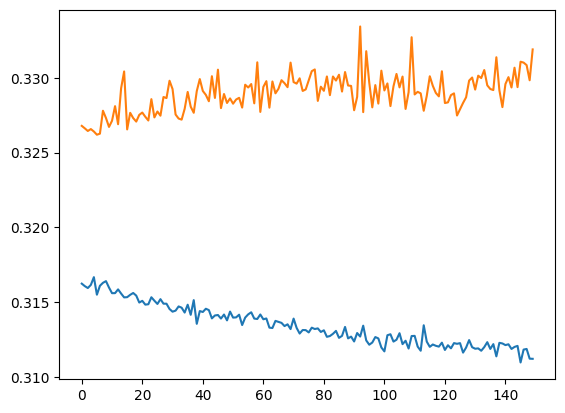

In [53]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

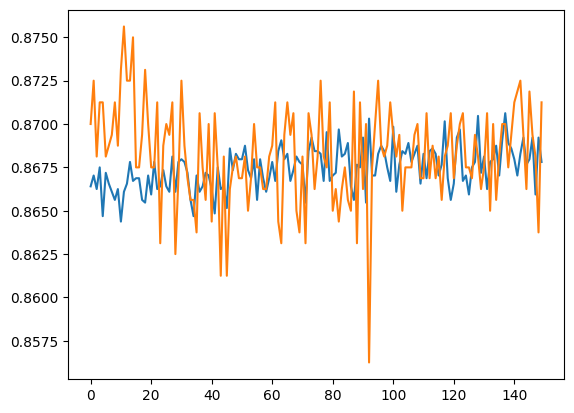

In [54]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])